## 📥 Data Collection

In [14]:
import config # config.py includes functions and configuration parameters
import yfinance as yf
import pandas as pd, numpy as np
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings("ignore")

TICKER = "BTC-USD"
PERIOD = "3y"
HORIZON = 5
TRAIN_SPLIT_RATIO = 0.8

In [15]:
# Downloading Data from Yahoo Finance

Ticker = yf.Ticker(ticker=f'{TICKER}')
df = Ticker.history(PERIOD)
start = df.index.min()
end = df.index.max()
sample_size = len(df)
print(f'✅ Downloaded {TICKER} data from {start} to {end}, total bars: {sample_size}')

✅ Downloaded BTC-USD data from 2023-04-12 00:00:00+00:00 to 2026-04-12 00:00:00+00:00, total bars: 1097


## 🛠️ Feature Engineering & Target Definition

In [16]:
# Features: Adding Some Technical Indicators

df["SMA9"] = df["Close"].rolling(window=9).mean()
df["SMA25"] = df["Close"].rolling(window=25).mean()
df["Log_Return_1d"] = df["Close"].pct_change()
df["Volatility9"] = df["Log_Return_1d"].rolling(window=9).std()
df["Close_SMA9_ratio"] = (df["Close"] - df["SMA9"]) / df["SMA9"]
df["Close_SMA25_ratio"] = (df["Close"] - df["SMA25"]) / df["SMA25"]
df["Close_High"] = df["Close"] / df["High"]
df["Close_Low"] = df["Close"] / df["Low"]
rsi = ta.momentum.RSIIndicator(close=df["Close"])
df["RSI"] = rsi.rsi()
df["Overbought"] = (df["RSI"] > 70).astype(int)
df["Oversold"] = (df["RSI"] < 30).astype(int)
macd = ta.trend.MACD(close=df["Close"])
df["MACD"] = macd.macd()
df["Signal_Line"] = macd.macd_signal()
df["MACD_Diff"] = ta.trend.macd_diff(df["Close"])
df["MACD_bullish"] = (df["MACD"] > 0).astype(int)
df["Bullish_Crossover"] = (df["MACD"] > df["Signal_Line"]).astype(int)
print(f"✅ Features Engineering is Done...")

✅ Features Engineering is Done...


In [17]:
# Target: 1 means Price of today + the defined <HORIZON> is higher than today's price, otherwise 0

df["Target"] = (df["Close"].shift(-HORIZON) > df["Close"]).astype(int)
df.dropna(inplace=True)
print(f"✅ Target is Defined and Data Cleaning is Done...")
print('\nClass Proportions:')
print(df['Target'].value_counts(normalize=True).sort_index())

✅ Target is Defined and Data Cleaning is Done...

Class Proportions:
Target
0    0.473684
1    0.526316
Name: proportion, dtype: float64


In [18]:
FEATURES = ["Volume","SMA9","Volatility9","Close_High","Overbought","Oversold","MACD_bullish","Bullish_Crossover"]
TARGET_LABELS = {0:'Down', 1:'Up'}

## 🧠 Model Selection & Cross-Validation

In [19]:
# Setting Train-Test Split

train_samples = int(df.shape[0] * TRAIN_SPLIT_RATIO)
train_data = df.iloc[:train_samples]
test_data = df.iloc[train_samples:]
X_train, y_train = train_data[FEATURES], train_data["Target"]
X_test, y_test = test_data[FEATURES], test_data["Target"]
test_samples = len(df) - train_samples
print(f"✅ Data split done. Train: {train_samples}, Test: {test_samples}")

✅ Data split done. Train: 851, Test: 213


In [20]:
# TimeSeries Cross-Validation

SPLITS = 5
tscv = TimeSeriesSplit(n_splits=SPLITS)
metrics = []
for train_idx, valid_idx in tscv.split(X_train, y_train):
    x_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    x_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

    model, _ = config.train_base_model(x_tr, y_tr, x_va, y_va, model_name="XGB")
    y_pred = model.predict(x_va)
    results = config.evaluate_model(y_va, y_pred, "XGB")
    metrics.append(results)
print("Cross Validation Results:\n", pd.DataFrame(metrics).to_string(max_colwidth=50))

Cross Validation Results:
   model  precision    recall        f1      confusion_matrix
0   XGB   0.612069  0.797753  0.692683   [[7, 45], [18, 71]]
1   XGB   0.307692  0.112676  0.164948   [[52, 18], [63, 8]]
2   XGB   0.694444  0.287356  0.406504  [[43, 11], [62, 25]]
3   XGB   0.519608  0.706667  0.598870  [[17, 49], [22, 53]]
4   XGB   0.833333  0.185185  0.303030   [[57, 3], [66, 15]]


In [21]:
# Building the final model on the full train/validation split 80:20

train_sample_size = int(X_train.shape[0] * TRAIN_SPLIT_RATIO)
x_tr, y_tr = X_train.iloc[:train_sample_size], y_train.iloc[:train_sample_size]
x_va, y_va = X_train.iloc[train_sample_size:], y_train.iloc[train_sample_size:]
model, _ = config.train_base_model(x_tr, y_tr, x_va, y_va, model_name="XGB")
y_pred = model.predict(x_va)
results = config.evaluate_model(y_va, y_pred, "XGB")
print("Validation data Results:\n", pd.DataFrame([results]).to_string(max_colwidth=50))

Validation data Results:
   model  precision    recall       f1    confusion_matrix
0   XGB        1.0  0.049505  0.09434  [[70, 0], [96, 5]]


In [22]:
# Applying the selected model on training data

y_train_pred = model.predict(X_train)
full_results = config.evaluate_model(y_train, y_train_pred, "XGB")
print("\nTrain Data Results:\n", pd.DataFrame([full_results]).to_string(max_colwidth=50))


Train Data Results:
   model  precision    recall       f1         confusion_matrix
0   XGB   0.720859  0.502137  0.59194  [[292, 91], [233, 235]]


In [23]:
# Applying on unseen test data

y_test_pred = model.predict(X_test)
test_results = config.evaluate_model(y_test, y_test_pred, "XGB")
print("Test Results:\n", pd.DataFrame([test_results]).to_string(max_colwidth=50))
print('\nTest Prediction Class proportions:')
print(pd.Series(y_test_pred).value_counts(normalize=True).sort_index())

Test Results:
   model  precision    recall        f1      confusion_matrix
0   XGB       0.45  0.097826  0.160714  [[110, 11], [83, 9]]

Test Prediction Class proportions:
0    0.906103
1    0.093897
Name: proportion, dtype: float64


## 📊 Backtesting & Results

In [24]:
df_test = test_data.copy()
df_test["pred"] = y_test_pred

# Correct mapping
signal_map = {0: -1, 1: 1}
df_test["signal"] = df_test["pred"].map(signal_map)

# Returns
df_test[f"ret_{HORIZON}d"] = df_test["Close"].pct_change(HORIZON)

# Apply with lag
df_test["strategy_ret"] = df_test["signal"].shift(1) * df_test[f"ret_{HORIZON}d"]

# Performance
cum_return = (1 + df_test["strategy_ret"]).cumprod()
sharpe = df_test["strategy_ret"].mean() / df_test["strategy_ret"].std() * np.sqrt(252)

print("Sharpe:", sharpe)

Sharpe: 0.39512792011702474


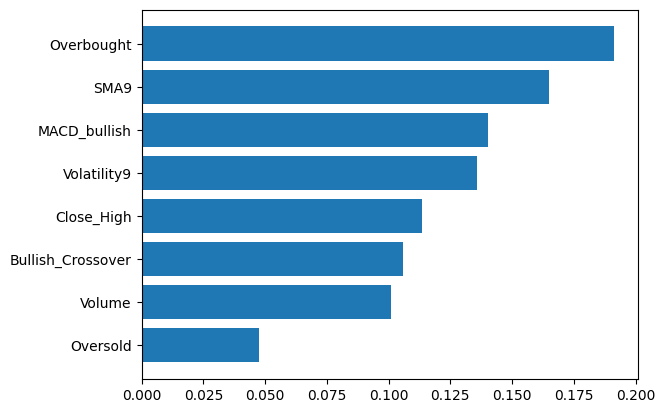

In [25]:
# Plotting Feature Importance

feature_importances = pd.DataFrame(
    {
        'Feature': X_train.columns,
        'Importance': model.feature_importances_
    }
).sort_values(by='Importance', ascending=True)
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.show()

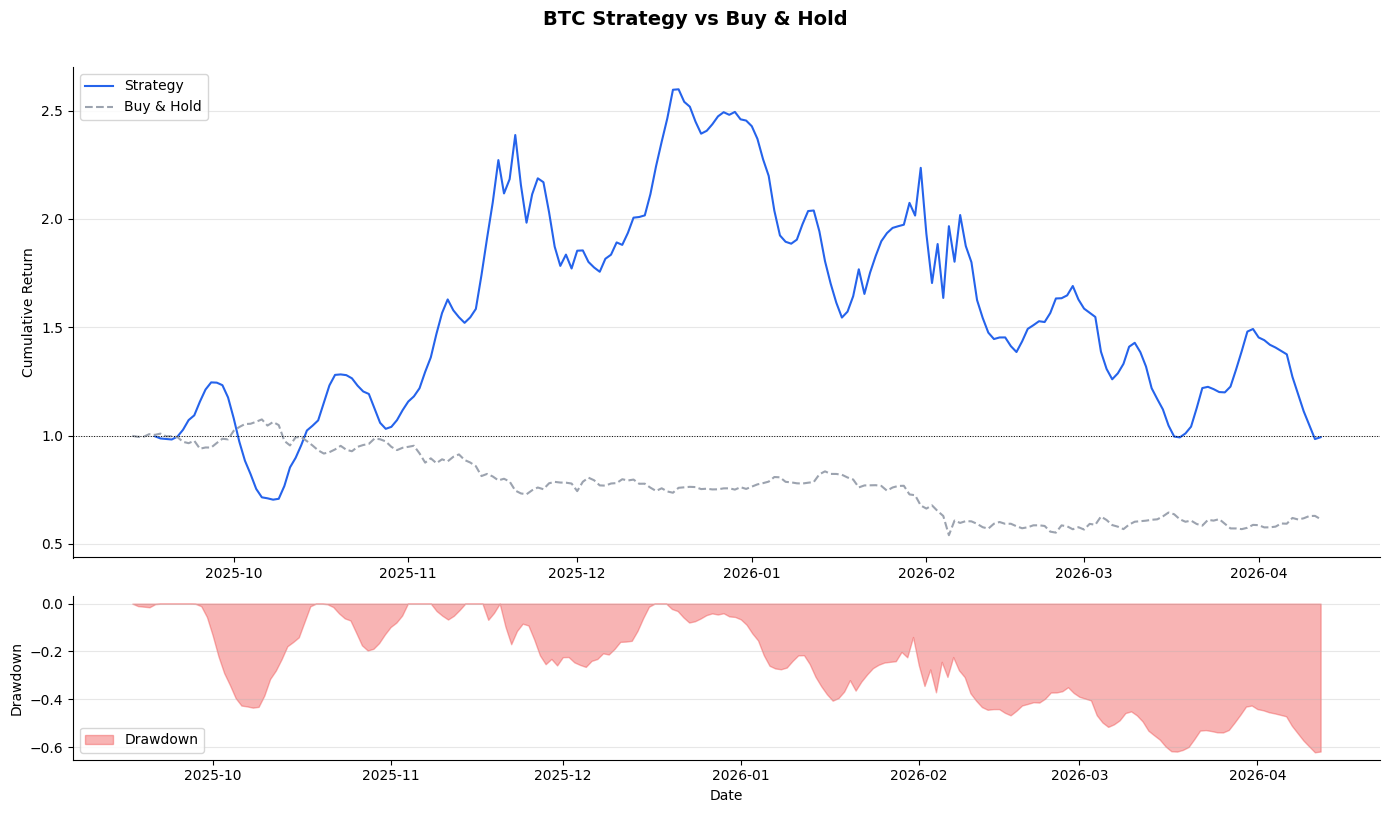

Strategy final return : 0.99x
Buy & Hold final return: 0.61x
Max drawdown           : -62.1%
Sharpe ratio           : 0.40


In [ ]:
# Cumulative Return: Strategy vs Buy & Hold

buy_and_hold = (1 + df_test["Close"].pct_change()).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("BTC Strategy vs Buy & Hold", fontsize=14, fontweight="bold", y=1.01)

# --- Top panel: cumulative returns ---
axes[0].plot(cum_return.index, cum_return.values, label="Strategy", color="#2563eb", linewidth=1.5)
axes[0].plot(buy_and_hold.index, buy_and_hold.values, label="Buy & Hold", color="#9ca3af", linewidth=1.5, linestyle="--")
axes[0].axhline(1, color="black", linewidth=0.7, linestyle=":")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend(loc="upper left")
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

# --- Bottom panel: drawdown ---
rolling_max = cum_return.cummax()
drawdown = (cum_return - rolling_max) / rolling_max
axes[1].fill_between(drawdown.index, drawdown.values, 0, color="#ef4444", alpha=0.4, label="Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend(loc="lower left")
axes[1].grid(axis="y", alpha=0.3)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

max_dd = drawdown.min()
final_strat = cum_return.iloc[-1]
final_bnh = buy_and_hold.iloc[-1]
print(f"Strategy final return : {final_strat:.2f}x")
print(f"Buy & Hold final return: {final_bnh:.2f}x")
print(f"Max drawdown           : {max_dd:.1%}")
print(f"Sharpe ratio           : {sharpe:.2f}")

the model shows promise in trending markets but degrades in regime changes, which motivates further work on walk-forward retraining.